# Matter Power Spectrum

In this notebook we are going to generate a matter density field, reproducing the distribution of matter on large scales in the Universe.
We will introduce Gaussian random filed and show how they can reproduce the early universe matter fluctuations


We will then see how cosmological parmaters affect the matter power spectrum. 

TODO: 
- introduce gaussian random fileds and properties: all the info is contained in the power spectrum 
- generate a white noise gaussian random fields
- then use camb to make a matter power spectrum
- make the map 
- compute the power spectrum for different cosmological parameters

Bonus: 
- CMB: compute the CMB power spectrum and make a map

Ultra bonus: 
- compute zeldovich displacement fields, i.e. perturbation theory ?

This notebook is inspired by Oliver Hahn lecture notes available here https://github.com/ohahn/LesHouches2025/blob/main/LSSfromGRF.ipynb
    

In [1]:
import numpy as np 
from matplotlib import pyplot as plt
import camb 

# 1. Gaussian Random fields


A lot of observables in cosmology can be described with a Gaussian random field (GRF). A GRF $f$ is defined as a set of random variables, parametrized over a domain $\mathcal{D} \subset \mathbb{R}^4$ such that for a finite set of points $\mathbf{x}_0, ... \mathbf{x}_{n} \in \mathcal{D}$, the random variables $f(\mathbf{x}_1), ... f(\mathbf{x}_n)$ are jointly Gaussian distributed. This joint distribution is fully specified by the mean vector $\mathbf{\mu}(\mathbf{x}_i)$ and the covariance matrix $(C)_{ij} = C(\mathbf{x}_i , \mathbf{x}_j)$
i.e.
$$
\mathbb{E}[f(\mathbf{x}_i)] = \mathbf{\mu}(\mathbf{x}_i)\, , 
$$
$$
\mathbb{E}\left[f(\mathbf{x}_i) f(\mathbf{x}_j)\right] = C(\mathbf{x}_i , \mathbf{x}_j) + \mathbf{\mu}(\mathbf{x}_i) \mathbf{\mu}(\mathbf{x}_i) \, .
$$

A field is centered if $\mu(\mathcal{x})=0, \, \forall \, x$. In the following we will work with centered field, as in practice we can simply re-define the field with $f-\mu$.  


A field is called **homogeneous** if the covariance is translation-invariant, i.e. if a function $\mathcal{C}$ exists so that
$$
C(\mathbf{x}_i , \mathbf{x}_j  ) = \mathcal{C}(\mathbf{x}_i − \mathbf{x}_ j ) \, .
$$

This function $ \mathcal{C}(\mathbf{r})$ is called the two point correlation function. 


A field is called **isotropic** if the covariance is rotation-invariant, i.e. if a function $\xi$ exists so that
$$
C(\mathbf{x}_i , \mathbf{x}_j  ) = \mathcal{\xi}(\left||\mathbf{x}_i − \mathbf{x}_ j \right||) 
$$
Note that if a field is isotropic in every point, then it is homogeneous. 



### Uncorrealted (white noise) GRF


A white Gaussian random field with no correlations has a normal distribution at every point, and the covariance between any two points is given by:
$$ C(\mathbf{x}, \mathbf{y}) = \sigma^2 \delta(\mathbf{x}- \mathbf{y})$$

where $\sigma$ is the variance of the field and $\delta$ is the Dirac delta function. This means that the values of the field at different points are independent (we also say uncorrelated) 



    

In [2]:
N = 256 # number of pixels in our map 

In [3]:
# create a Gaussian random field of size N**2
sigma2 = 1.0
delta0 = np.random.normal(size=[N,N]) * np.sqrt(sigma2)


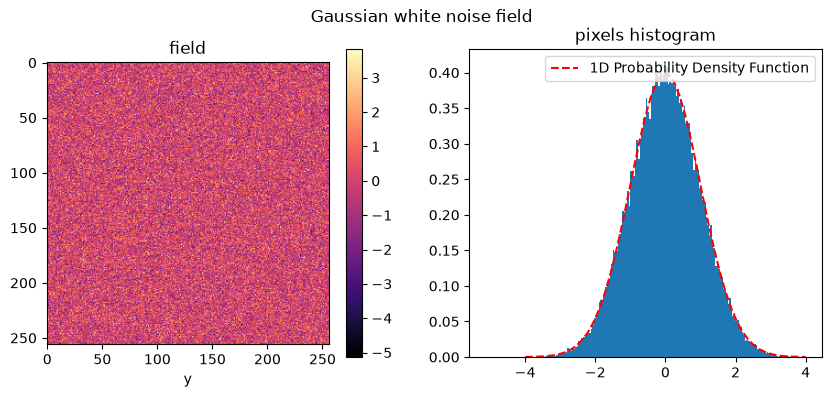

In [4]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
fig.suptitle('Gaussian white noise field')
im = ax[0].imshow(delta0, cmap='magma')
fig.colorbar(im, ax=ax[0])

ax[1].hist(delta0.flatten(),bins=200,density=True);

xx = np.linspace(-4*np.sqrt(sigma2), 4*np.sqrt(sigma2))
ax[1].plot(xx, 1/np.sqrt(2*np.pi*sigma2) * np.exp(-xx**2 / 2 / sigma2), ls='--', color='red',  label='1D Probability Density Function')


ax[0].set_xlabel('x')
ax[0].set_xlabel('y')
ax[0].set_title('field')


ax[1].set_title('pixels histogram')
ax[1].legend()

# 2. Matter power spectrum


TODO:  introduce power spectrum 

The power spectrum is defined as ....




CAMB is a cosmology library taht allows to predict several cosmological observables, giving as input a cosmological model and cosmological parameter values. 

We will assume the LCDM model, and the default comsological parmaeter values from CAMB. 



In [5]:
#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)
pars.set_matter_power(redshifts=(1./np.linspace(0.1,1.0,10)-1), kmax=100.0)

#Linear spectra
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)
PK = camb.get_matter_power_interpolator(pars, nonlinear=False, kmax=1e2, var1='delta_tot',zmin=0.0, zmax=10.0)
s8 = np.array(results.get_sigma8())

print(f'sigma_8(z=0) = {s8[-1]}')


sigma_8(z=0) = 0.802690264717793


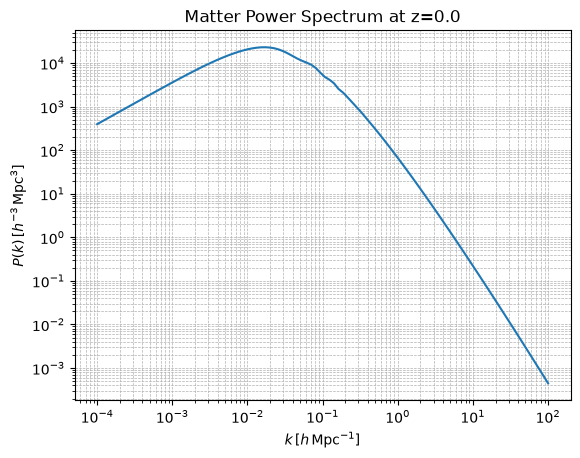

In [6]:
# Define the range of k values
k_values = np.logspace(-4, 2, 100)  # k values from 10^-3 to 10^2

# Get the power spectrum at z=0
zout = 0.0
P_k = PK.P(0.0, k_values)

# Plot the power spectrum
fig, ax = plt.subplots()
ax.loglog(k_values, P_k, label='Power Spectrum (z=0)')
ax.set_xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) \, [h^{-3} \, \mathrm{Mpc}^3]$')
ax.set_title(f'Matter Power Spectrum at z={zout}')
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

In [7]:
Lbox = 1000.  # define the patch in Mpc/h
k0   = 2*np.pi / Lbox # the fundamental mode 

# set up Fourier mode indexing
kx = np.fft.fftfreq(N) * k0 * N
ky = np.fft.fftfreq(N) * k0 * N

kvec = np.array(np.meshgrid(kx,ky))
kmod = np.sqrt(np.sum(kvec**2,axis=0))
kny = k0 * N/2 # Nyquist freq

To generate an uncorrelated GRF for a given power spectrum, we take the one initialised with the normal distribution above, and multiply its Fourier coefficients by the desired power. 

In [8]:
kcut = 0.1 * kny


fdelta0 = np.fft.fft2(delta0)
fdelta = fdelta0 * np.sqrt(PK.P(zout,kmod)) * N**1.5 / Lbox**1.5 #* np.exp(-0.5*(kmod/kcut)**2)
delta  = np.fft.fft2(fdelta)

/opt/homebrew/Caskroom/miniforge/base/envs/cosmoschool/lib/python3.14/site-packages/camb/results.py:1105: RuntimeWarning: divide by zero encountered in log
  return self.logsign * np.exp(self(z, np.log(kh), grid=grid))


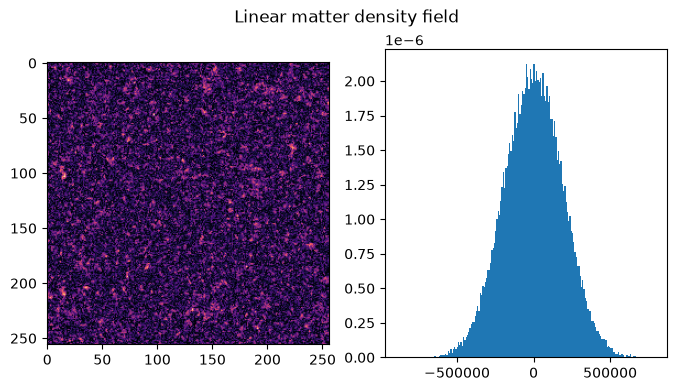

In [10]:
fig, ax = plt.subplots(1,2,figsize=(8,4))
fig.suptitle('Linear matter density field')
ax[0].imshow(np.abs(delta), cmap='magma')
ax[1].hist(delta.flatten(),bins=200,density=True);
